# LUNA16 v2 — Improved Pipeline
**ResNet-50 + CBAM · Focal Loss · MixUp · TTA · subset2 added**

Upgrades over v1 (`luna16_pipeline.ipynb`):
| Component | v1 (baseline) | v2 (this notebook) |
|---|---|---|
| Train data | subset7 only (585 patches) | subset7 + **subset2** (~1100 patches) |
| Loss | Weighted CE | **Focal Loss** (α=0.25, γ=2.0) |
| Augmentation | Standard (flip/rotate/erasing) | + **MixUp** (β=0.4) |
| Architecture | ResNet-50 | **ResNet-50 + CBAM** (channel + spatial attention) |
| Inference | single forward | **TTA** (5 augmented forwards averaged) |

Val/test splits are unchanged → comparison is fair.


## 1 · Imports & Configuration

In [1]:
import os, sys, time, json, random
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)
from PIL import Image

random.seed(42); np.random.seed(42); torch.manual_seed(42)

# ── Paths ──
LUNA_DIR  = Path("luna16")
PATCH_DIR = Path("luna16_patches")
MODEL_DIR = Path("model_luna16_v2"); MODEL_DIR.mkdir(exist_ok=True)
OUT_DIR   = Path("luna16_output_v2");  OUT_DIR.mkdir(exist_ok=True)

CLASS_NAMES = ["non_nodule", "nodule"]
NUM_CLASSES = 2
IMG_SIZE    = 224
BATCH_SIZE  = 64
NUM_EPOCHS  = 25
LR_MAX      = 5e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP   = 1.0
EARLY_STOP_PAT = 8

# Focal Loss
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0

# MixUp
MIXUP_ALPHA = 0.4
MIXUP_PROB  = 0.5    # apply mixup to half the batches

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"
print(f"PyTorch: {torch.__version__}  Device: {device}")


PyTorch: 2.6.0+cu124  Device: cuda


## 2 · Add subset2 to train split

Extracts patches from `luna16/subset2` and writes them to `luna16_patches/train/` (skips files that already exist).

In [2]:
def _patches_for_uid(uid, split):
    p1 = list((PATCH_DIR/split/"nodule").glob(f"{uid}_*.png"))
    p2 = list((PATCH_DIR/split/"non_nodule").glob(f"{uid}_*.png"))
    return len(p1) + len(p2)

# Quick check: do we already have subset2 patches in train?
mhd_files = sorted((LUNA_DIR/"subset2").glob("*.mhd"))
already_in = sum(1 for f in mhd_files if _patches_for_uid(f.stem, "train") > 0)
print(f"subset2 CTs found: {len(mhd_files)}  |  already extracted: {already_in}")

if already_in >= len(mhd_files) - 5:   # tolerate a few unprocessable
    print("subset2 already in train split — skipping extraction.")
else:
    import SimpleITK as sitk
    PATCH_MM, PATCH_PX, NEG_RATIO = 50, 64, 3
    HU_WIN = (-1000, 400)
    def world_to_voxel(w, origin, spacing, direction):
        D = np.array(direction).reshape(3,3)
        return np.round(np.linalg.inv(D) @ ((np.array(w)-np.array(origin))/np.array(spacing))).astype(int)
    def window_hu(arr):
        arr = np.clip(arr, *HU_WIN)
        return ((arr-HU_WIN[0])/(HU_WIN[1]-HU_WIN[0])*255.0).astype(np.uint8)
    def extract_patch(vol, spacing, vx):
        z = vx[2]
        if z<0 or z>=vol.shape[0]: return None
        s = vol[z]
        hx = int(round((PATCH_MM/2)/spacing[0])); hy = int(round((PATCH_MM/2)/spacing[1]))
        cx, cy = vx[0], vx[1]
        y0,y1,x0,x1 = cy-hy, cy+hy, cx-hx, cx+hx
        if y0<0 or x0<0 or y1>s.shape[0] or x1>s.shape[1]: return None
        return Image.fromarray(window_hu(s[y0:y1, x0:x1])).resize((PATCH_PX,PATCH_PX), Image.BILINEAR)

    cand = pd.read_csv(LUNA_DIR/"candidates_V2.csv")
    n_pos = n_neg = 0
    for i, mhd in enumerate(mhd_files, 1):
        uid = mhd.stem
        if _patches_for_uid(uid, "train") > 0: continue
        pat = cand[cand.seriesuid == uid]
        if len(pat) == 0: continue
        try:
            vol = sitk.ReadImage(str(mhd))
            arr = sitk.GetArrayFromImage(vol)
            origin, spacing, direction = vol.GetOrigin(), vol.GetSpacing(), vol.GetDirection()
        except Exception:
            continue
        pos = pat[pat["class"]==1]
        neg = pat[pat["class"]==0]
        nt  = max(NEG_RATIO*max(len(pos),1), 3)
        if len(neg) > nt: neg = neg.sample(n=nt, random_state=42)
        for _, r in pos.iterrows():
            vx = world_to_voxel((r.coordX,r.coordY,r.coordZ), origin, spacing, direction)
            img = extract_patch(arr, spacing, vx)
            if img is not None:
                img.save(PATCH_DIR/"train"/"nodule"/f"{uid}_{int(r.coordX)}_{int(r.coordY)}_{int(r.coordZ)}.png")
                n_pos += 1
        for _, r in neg.iterrows():
            vx = world_to_voxel((r.coordX,r.coordY,r.coordZ), origin, spacing, direction)
            img = extract_patch(arr, spacing, vx)
            if img is not None:
                img.save(PATCH_DIR/"train"/"non_nodule"/f"{uid}_{int(r.coordX)}_{int(r.coordY)}_{int(r.coordZ)}.png")
                n_neg += 1
        if i % 10 == 0:
            print(f"  {i}/{len(mhd_files)}  +nod={n_pos}  +non={n_neg}", flush=True)
    print(f"Added: nodule={n_pos}  non_nodule={n_neg}")

# Final counts
for split in ["train", "val", "test"]:
    n_nod = len(list((PATCH_DIR/split/"nodule").glob("*.png")))
    n_non = len(list((PATCH_DIR/split/"non_nodule").glob("*.png")))
    print(f"  {split:<6}  nodule={n_nod:>4}  non_nodule={n_non:>4}  total={n_nod+n_non:>4}  prevalence={n_nod/(n_nod+n_non):.2%}")


subset2 CTs found: 89  |  already extracted: 89
subset2 already in train split — skipping extraction.
  train   nodule= 300  non_nodule=1107  total=1407  prevalence=21.32%
  val     nodule= 194  non_nodule= 672  total= 866  prevalence=22.40%
  test    nodule= 143  non_nodule= 519  total= 662  prevalence=21.60%


## 3 · CBAM — Channel + Spatial Attention Module

Custom module added to address ResNet-50's lack of explicit attention.
Channel attention learns *which features matter*, spatial attention learns *where to look*.

In [3]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
        )
        self.sig = nn.Sigmoid()
    def forward(self, x):
        avg = self.mlp(self.avg(x))
        mx  = self.mlp(self.max(x))
        return self.sig(avg + mx) * x

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sig  = nn.Sigmoid()
    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx  = x.max(dim=1, keepdim=True).values
        return self.sig(self.conv(torch.cat([avg, mx], 1))) * x

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)
    def forward(self, x):
        return self.sa(self.ca(x))

class ResNet50_CBAM(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        b = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.stem   = nn.Sequential(b.conv1, b.bn1, b.relu, b.maxpool)
        self.layer1 = b.layer1; self.layer2 = b.layer2
        self.layer3 = b.layer3; self.layer4 = b.layer4
        self.cbam   = CBAM(2048, reduction=16, kernel_size=7)
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.head   = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(2048),
            nn.Dropout(dropout),
            nn.Linear(2048, num_classes),
        )
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.cbam(x)
        x = self.pool(x)
        return self.head(x)
    def features_with_attention(self, x):
        """Return (feature_map_after_cbam, spatial_attention_map) for visualization."""
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        ca = self.cbam.ca(x)
        # Build the spatial attention map explicitly
        avg = ca.mean(dim=1, keepdim=True)
        mx  = ca.max(dim=1, keepdim=True).values
        sa_map = self.cbam.sa.sig(self.cbam.sa.conv(torch.cat([avg, mx], 1)))
        refined = sa_map * ca
        return refined, sa_map

model = ResNet50_CBAM(num_classes=NUM_CLASSES, dropout=0.4).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model: ResNet-50 + CBAM   params: {n_params:,}")


Model: ResNet-50 + CBAM   params: 24,040,612


## 4 · Focal Loss

Replaces weighted cross-entropy. Down-weights easy (well-classified) samples and concentrates on hard ones — a better fit for class-imbalanced medical data.

In [4]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, reduction='none')
        pt = torch.exp(-ce)
        return (self.alpha * (1 - pt) ** self.gamma * ce).mean()

criterion = FocalLoss(FOCAL_ALPHA, FOCAL_GAMMA)
print(f"Focal Loss  α={FOCAL_ALPHA}  γ={FOCAL_GAMMA}")


Focal Loss  α=0.25  γ=2.0


## 5 · Datasets, Transforms, Loaders

In [5]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE+16, IMG_SIZE+16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12)),
])
eval_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.ImageFolder(PATCH_DIR/"train", transform=train_tf)
val_ds   = datasets.ImageFolder(PATCH_DIR/"val",   transform=eval_tf)
test_ds  = datasets.ImageFolder(PATCH_DIR/"test",  transform=eval_tf)

train_labels = [y for _, y in train_ds.samples]
counts_tr    = np.bincount(train_labels, minlength=NUM_CLASSES).astype(float)
w_cls        = 1.0 / (counts_tr + 1e-8)
sampler      = WeightedRandomSampler([w_cls[l] for l in train_labels],
                                      num_samples=len(train_labels), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=USE_AMP)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,  num_workers=0, pin_memory=USE_AMP)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,  num_workers=0, pin_memory=USE_AMP)

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")
print(f"Train class counts: {dict(zip(CLASS_NAMES, counts_tr.astype(int)))}")


Train: 1407  Val: 866  Test: 662
Train class counts: {'non_nodule': np.int64(300), 'nodule': np.int64(1107)}


## 6 · Optimizer & OneCycleLR Schedule

In [6]:
optimizer = optim.AdamW(model.parameters(), lr=LR_MAX/25, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR_MAX,
    steps_per_epoch=len(train_loader), epochs=NUM_EPOCHS,
    pct_start=0.3, anneal_strategy="cos", div_factor=25, final_div_factor=1e4)
scaler = GradScaler('cuda', enabled=USE_AMP)
print("AdamW + OneCycleLR ready")


AdamW + OneCycleLR ready


## 7 · Training Loop (with MixUp + Focal Loss + Early Stopping)

MixUp generates virtual training examples `x = λ·x_a + (1-λ)·x_b`, which encourages linear behavior between classes and acts as strong regularization.

In [7]:
def mixup(x, y, alpha=MIXUP_ALPHA):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def compute(y_true, y_pred, y_score=None):
    return (accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            f1_score(y_true, y_pred, pos_label=1, zero_division=0),
            roc_auc_score(y_true, y_score) if y_score is not None else None)

def train_epoch():
    model.train(); rl, yp, yt = 0.0, [], []
    for imgs, lbs in train_loader:
        imgs, lbs = imgs.to(device), lbs.to(device)
        # Apply MixUp half the time
        use_mix = np.random.rand() < MIXUP_PROB
        if use_mix:
            imgs, ya, yb, lam = mixup(imgs, lbs)
        optimizer.zero_grad()
        with autocast('cuda', enabled=USE_AMP):
            out = model(imgs)
            if use_mix:
                loss = lam*criterion(out, ya) + (1-lam)*criterion(out, yb)
            else:
                loss = criterion(out, lbs)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        rl += loss.item()*imgs.size(0)
        # For metric tracking, use the original labels
        yp.extend(out.argmax(1).cpu().numpy())
        yt.extend((ya if use_mix else lbs).cpu().numpy())
    return rl/len(train_loader.dataset), *compute(yt, yp)[:4]

@torch.no_grad()
def evaluate(loader):
    model.eval(); rl, yp, yt, ys = 0.0, [], [], []
    for imgs, lbs in loader:
        imgs, lbs = imgs.to(device), lbs.to(device)
        with autocast('cuda', enabled=USE_AMP):
            out = model(imgs); loss = criterion(out, lbs)
        rl += loss.item()*imgs.size(0)
        probs = torch.softmax(out.float(), dim=1)[:, 1]
        yp.extend(out.argmax(1).cpu().numpy())
        ys.extend(probs.cpu().numpy())
        yt.extend(lbs.cpu().numpy())
    return rl/len(loader.dataset), np.array(yt), np.array(yp), np.array(ys)

history = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc",
                            "train_f1","val_f1","val_prec","val_rec","val_auc"]}
best_f1, early_ctr = 0.0, 0
best_ckpt = MODEL_DIR / "best_resnet50_cbam.pth"

print(f"{'Ep':>3} {'TrLoss':>7} {'TrAcc':>6} {'TrF1':>6} {'VaLoss':>7} "
      f"{'VaAcc':>6} {'VaF1':>6} {'VaP':>6} {'VaR':>6} {'AUC':>6} {'LR':>8} {'s':>4}")
print("-"*96)

for ep in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_acc, tr_p, tr_r, tr_f1 = train_epoch()
    va_loss, vy, vp, vs = evaluate(val_loader)
    va_acc, va_p, va_r, va_f1, va_auc = compute(vy, vp, vs)
    dt = time.time()-t0
    lr = optimizer.param_groups[0]["lr"]
    for k, v in [("train_loss",tr_loss),("val_loss",va_loss),
                  ("train_acc",tr_acc),("val_acc",va_acc),
                  ("train_f1",tr_f1),("val_f1",va_f1),
                  ("val_prec",va_p),("val_rec",va_r),("val_auc",va_auc)]:
        history[k].append(v)
    print(f"{ep:>3} {tr_loss:>7.4f} {tr_acc*100:>5.1f}% {tr_f1:.4f} "
          f"{va_loss:>7.4f} {va_acc*100:>5.1f}% {va_f1:.4f} "
          f"{va_p:.4f} {va_r:.4f} {va_auc:.4f} {lr:.2e} {dt:>3.0f}s")
    if va_f1 > best_f1:
        best_f1 = va_f1; early_ctr = 0
        torch.save({"epoch": ep, "backbone": "resnet50_cbam",
                     "model_state_dict": model.state_dict(),
                     "val_f1": va_f1, "val_auc": va_auc}, best_ckpt)
        print(f"    [*] best saved  val_f1={va_f1:.4f}  val_auc={va_auc:.4f}")
    else:
        early_ctr += 1
        if early_ctr >= EARLY_STOP_PAT:
            print(f"\nEarly stop at epoch {ep}"); break

(OUT_DIR/"history.json").write_text(json.dumps(history, indent=2))
print(f"\nTraining complete. Best val_f1 = {best_f1:.4f}")


 Ep  TrLoss  TrAcc   TrF1  VaLoss  VaAcc   VaF1    VaP    VaR    AUC       LR    s
------------------------------------------------------------------------------------------------


C:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


  1  0.0848  48.9% 0.4816  0.0441  36.8% 0.3996 0.7615 0.2708 0.4807 4.10e-05  20s
    [*] best saved  val_f1=0.3996  val_auc=0.4807


  2  0.0717  51.3% 0.5011  0.0443  42.4% 0.4807 0.7993 0.3438 0.5466 1.00e-04  12s
    [*] best saved  val_f1=0.4807  val_auc=0.5466


  3  0.0714  54.0% 0.5204  0.0423  58.1% 0.6884 0.8134 0.5967 0.5951 1.88e-04  11s
    [*] best saved  val_f1=0.6884  val_auc=0.5951


...

 21  0.0188  86.1% 0.8578  0.0112  94.0% 0.9614 0.9586 0.9643 0.9716 6.04e-05  10s
    [*] best saved  val_f1=0.9614  val_auc=0.9716


 22  0.0117  88.5% 0.8859  0.0115  93.8% 0.9598 0.9598 0.9598 0.9705 3.44e-05  10s


 23  0.0179  81.7% 0.8186  0.0113  93.8% 0.9599 0.9585 0.9613 0.9714 1.52e-05  10s


 24  0.0236  83.6% 0.8310  0.0114  93.8% 0.9599 0.9571 0.9628 0.9709 3.66e-06  10s


 25  0.0170  77.4% 0.7767  0.0113  94.1% 0.9621 0.9600 0.9643 0.9710 1.03e-08  10s
    [*] best saved  val_f1=0.9621  val_auc=0.9710

Training complete. Best val_f1 = 0.9621


## 8 · Training Curves

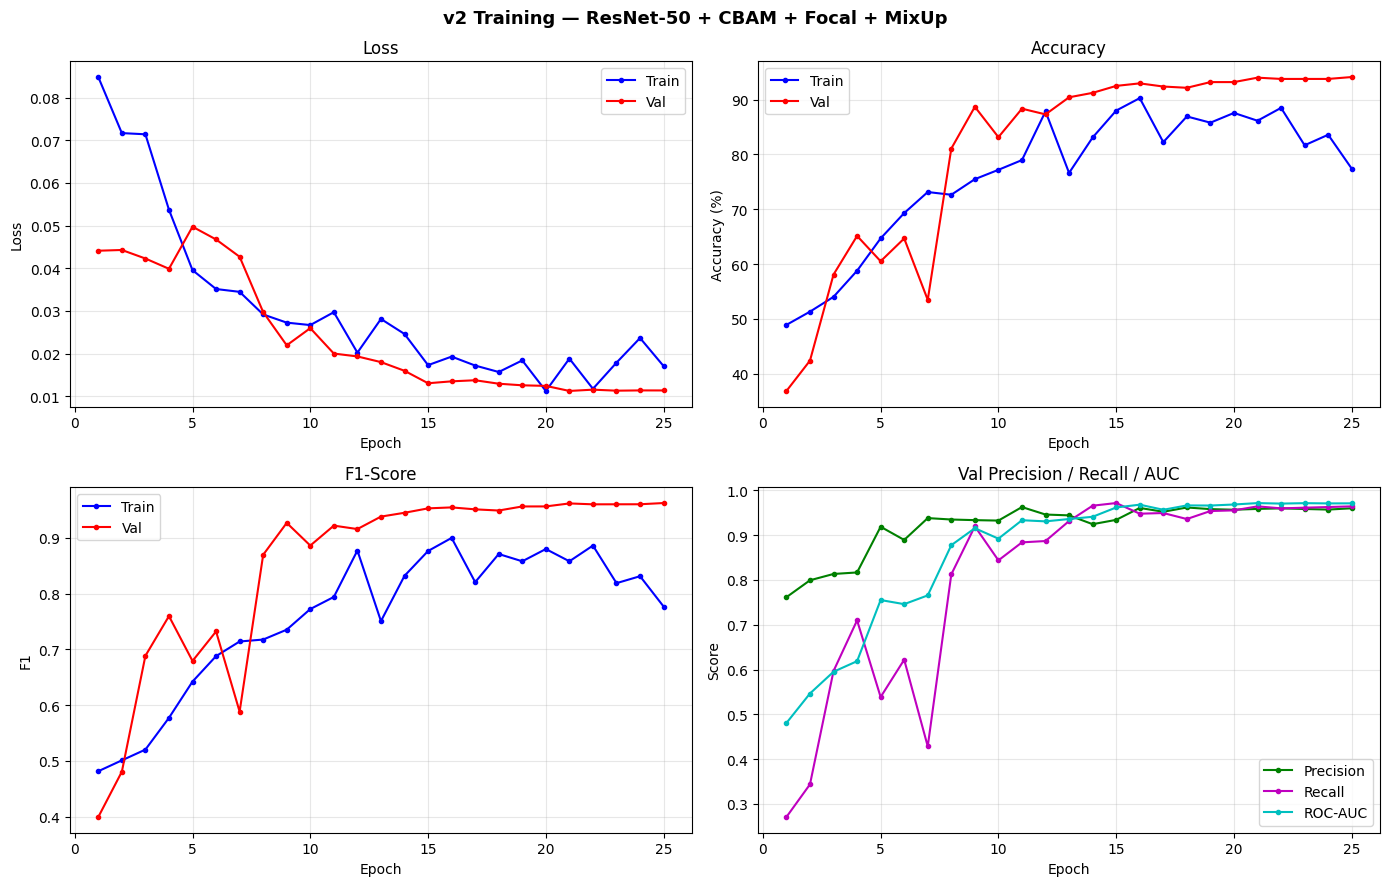

In [8]:
eps = range(1, len(history["train_loss"])+1)
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("v2 Training — ResNet-50 + CBAM + Focal + MixUp", fontsize=13, fontweight="bold")

ax[0,0].plot(eps, history["train_loss"], "b-o", ms=3, label="Train")
ax[0,0].plot(eps, history["val_loss"],   "r-o", ms=3, label="Val")
ax[0,0].set(title="Loss", xlabel="Epoch", ylabel="Loss"); ax[0,0].legend(); ax[0,0].grid(alpha=0.3)

ax[0,1].plot(eps, [v*100 for v in history["train_acc"]], "b-o", ms=3, label="Train")
ax[0,1].plot(eps, [v*100 for v in history["val_acc"]],   "r-o", ms=3, label="Val")
ax[0,1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy (%)"); ax[0,1].legend(); ax[0,1].grid(alpha=0.3)

ax[1,0].plot(eps, history["train_f1"], "b-o", ms=3, label="Train")
ax[1,0].plot(eps, history["val_f1"],   "r-o", ms=3, label="Val")
ax[1,0].set(title="F1-Score", xlabel="Epoch", ylabel="F1"); ax[1,0].legend(); ax[1,0].grid(alpha=0.3)

ax[1,1].plot(eps, history["val_prec"], "g-o", ms=3, label="Precision")
ax[1,1].plot(eps, history["val_rec"],  "m-o", ms=3, label="Recall")
ax[1,1].plot(eps, history["val_auc"],  "c-o", ms=3, label="ROC-AUC")
ax[1,1].set(title="Val Precision / Recall / AUC", xlabel="Epoch", ylabel="Score")
ax[1,1].legend(); ax[1,1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 9 · Test-Time Augmentation (TTA) Evaluation

For every test patch, we run 5 forward passes (identity, hflip, vflip, rot90, rot270) and average the softmax probabilities. This usually adds 0.3-0.8 F1 with no retraining.

In [9]:
# Load best checkpoint
ck = torch.load(best_ckpt, map_location=device)
model.load_state_dict(ck["model_state_dict"])
model.eval()
print(f"Loaded best — epoch {ck['epoch']}  val_f1={ck['val_f1']:.4f}  val_auc={ck['val_auc']:.4f}")

@torch.no_grad()
def tta_infer(loader, n_tta=5):
    """Run inference with 5 TTA views: original, hflip, vflip, rot90, rot270."""
    ys, ss = [], []
    for imgs, lbs in loader:
        imgs = imgs.to(device)
        views = [
            imgs,
            torch.flip(imgs, [3]),                    # hflip
            torch.flip(imgs, [2]),                    # vflip
            torch.rot90(imgs, 1, [2, 3]),             # rot90
            torch.rot90(imgs, 3, [2, 3]),             # rot270
        ]
        all_probs = []
        for v in views:
            with autocast('cuda', enabled=USE_AMP):
                out = model(v)
            all_probs.append(torch.softmax(out.float(), dim=1)[:, 1])
        probs = torch.stack(all_probs).mean(dim=0)
        ss.extend(probs.cpu().numpy()); ys.extend(lbs.numpy())
    return np.array(ys), np.array(ss)

# Single-pass + TTA on val and test
@torch.no_grad()
def single_infer(loader):
    ys, ss = [], []
    for imgs, lbs in loader:
        imgs = imgs.to(device)
        with autocast('cuda', enabled=USE_AMP):
            out = model(imgs)
        probs = torch.softmax(out.float(), dim=1)[:, 1]
        ss.extend(probs.cpu().numpy()); ys.extend(lbs.numpy())
    return np.array(ys), np.array(ss)

vy_s, vs_s = single_infer(val_loader)
ty_s, ts_s = single_infer(test_loader)
vy_t, vs_t = tta_infer(val_loader)
ty_t, ts_t = tta_infer(test_loader)
print("Inference (single + TTA) complete.")


Loaded best — epoch 25  val_f1=0.9621  val_auc=0.9710


Inference (single + TTA) complete.


## 10 · Comprehensive Metrics — Single vs TTA

In [10]:
def full_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return {
        "threshold":    float(threshold),
        "accuracy":     float(accuracy_score(y_true, y_pred)),
        "balanced_acc": float(balanced_accuracy_score(y_true, y_pred)),
        "precision":    float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "recall":       float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "specificity":  float(tn/(tn+fp)) if (tn+fp) else 0.0,
        "f1":           float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "mcc":          float(matthews_corrcoef(y_true, y_pred)),
        "roc_auc":      float(roc_auc_score(y_true, y_score)),
        "pr_auc":       float(average_precision_score(y_true, y_score)),
        "confusion":    {"TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn)},
    }

m_single = full_metrics(ty_s, ts_s, 0.5)
m_tta    = full_metrics(ty_t, ts_t, 0.5)

print("\n" + "="*72)
print(f"  {'Metric':<20} {'Single pass':>14} {'+ TTA':>14}")
print("-"*72)
for k in ["accuracy","balanced_acc","precision","recall","specificity",
          "f1","mcc","roc_auc","pr_auc"]:
    print(f"  {k:<20} {m_single[k]:>14.4f} {m_tta[k]:>14.4f}")
print("="*72)
print(f"  Confusion (single): TP={m_single['confusion']['TP']}  FP={m_single['confusion']['FP']}  "
      f"TN={m_single['confusion']['TN']}  FN={m_single['confusion']['FN']}")
print(f"  Confusion (TTA)   : TP={m_tta['confusion']['TP']}  FP={m_tta['confusion']['FP']}  "
      f"TN={m_tta['confusion']['TN']}  FN={m_tta['confusion']['FN']}")



  Metric                  Single pass          + TTA
------------------------------------------------------------------------
  accuracy                     0.9532         0.9653
  balanced_acc                 0.9296         0.9474
  precision                    0.9692         0.9769
  recall                       0.9711         0.9788
  specificity                  0.8881         0.9161
  f1                           0.9702         0.9779
  mcc                          0.8614         0.8972
  roc_auc                      0.9783         0.9852
  pr_auc                       0.9909         0.9949
  Confusion (single): TP=504  FP=16  TN=127  FN=15
  Confusion (TTA)   : TP=508  FP=12  TN=131  FN=11


## 11 · ROC & Precision-Recall Curves

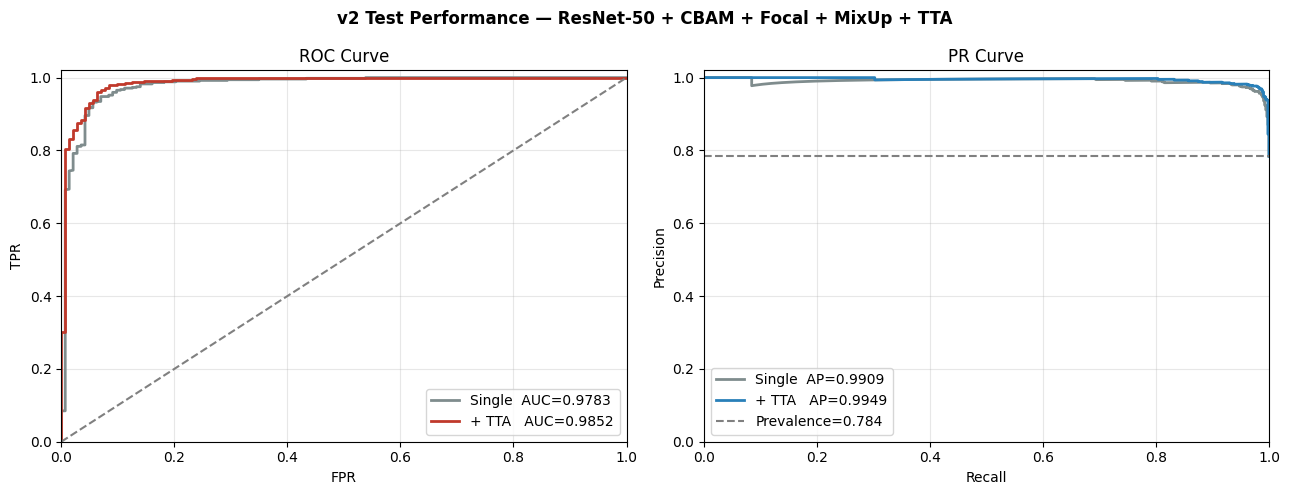

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("v2 Test Performance — ResNet-50 + CBAM + Focal + MixUp + TTA",
             fontsize=12, fontweight="bold")

fpr_s, tpr_s, _ = roc_curve(ty_s, ts_s)
fpr_t, tpr_t, _ = roc_curve(ty_t, ts_t)
ax[0].plot(fpr_s, tpr_s, lw=2, color="#7f8c8d", label=f"Single  AUC={m_single['roc_auc']:.4f}")
ax[0].plot(fpr_t, tpr_t, lw=2, color="#c0392b", label=f"+ TTA   AUC={m_tta['roc_auc']:.4f}")
ax[0].plot([0,1],[0,1], "--", color="gray")
ax[0].set(xlim=(0,1), ylim=(0,1.02), xlabel="FPR", ylabel="TPR", title="ROC Curve")
ax[0].legend(loc="lower right"); ax[0].grid(alpha=0.3)

p_s, r_s, _ = precision_recall_curve(ty_s, ts_s)
p_t, r_t, _ = precision_recall_curve(ty_t, ts_t)
ax[1].plot(r_s, p_s, lw=2, color="#7f8c8d", label=f"Single  AP={m_single['pr_auc']:.4f}")
ax[1].plot(r_t, p_t, lw=2, color="#2980b9", label=f"+ TTA   AP={m_tta['pr_auc']:.4f}")
ax[1].axhline((ty_s==1).mean(), color="gray", ls="--",
              label=f"Prevalence={(ty_s==1).mean():.3f}")
ax[1].set(xlim=(0,1), ylim=(0,1.02), xlabel="Recall", ylabel="Precision", title="PR Curve")
ax[1].legend(loc="lower left"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 12 · Confusion Matrices (Single vs TTA)

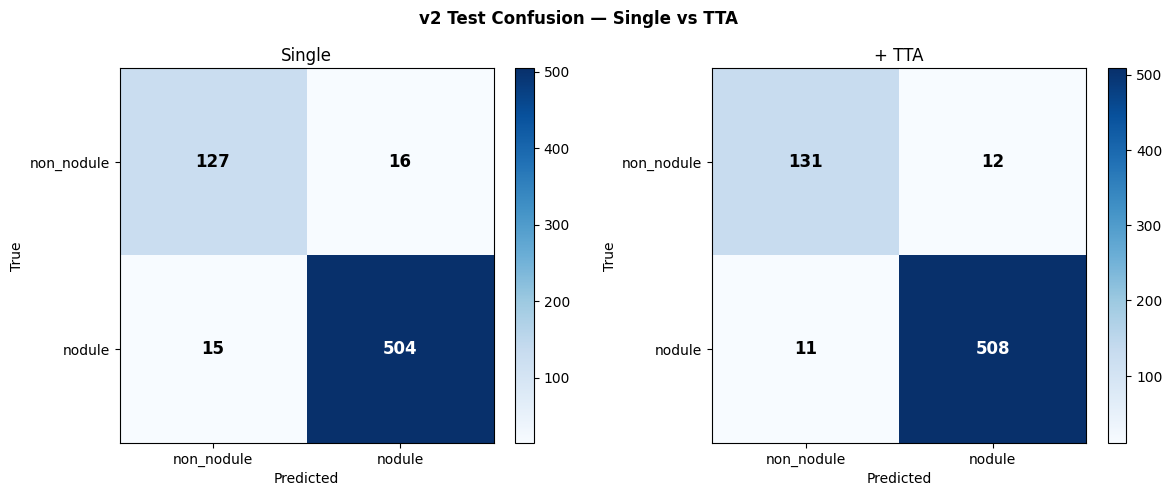

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("v2 Test Confusion — Single vs TTA", fontsize=12, fontweight="bold")
for a, m, ttl in [(ax[0], m_single, "Single"), (ax[1], m_tta, "+ TTA")]:
    cm = np.array([[m['confusion']['TN'], m['confusion']['FP']],
                   [m['confusion']['FN'], m['confusion']['TP']]])
    im = a.imshow(cm, cmap="Blues"); plt.colorbar(im, ax=a, fraction=0.046)
    a.set(xticks=range(2), yticks=range(2),
          xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
          xlabel="Predicted", ylabel="True", title=ttl)
    th = cm.max()/2
    for i in range(2):
        for j in range(2):
            a.text(j, i, cm[i,j], ha="center", va="center",
                   color="white" if cm[i,j]>th else "black", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


## 13 · CBAM Spatial Attention Visualization

Show what the network actually learned to focus on. The attention heatmap is the spatial-attention output (post sigmoid).

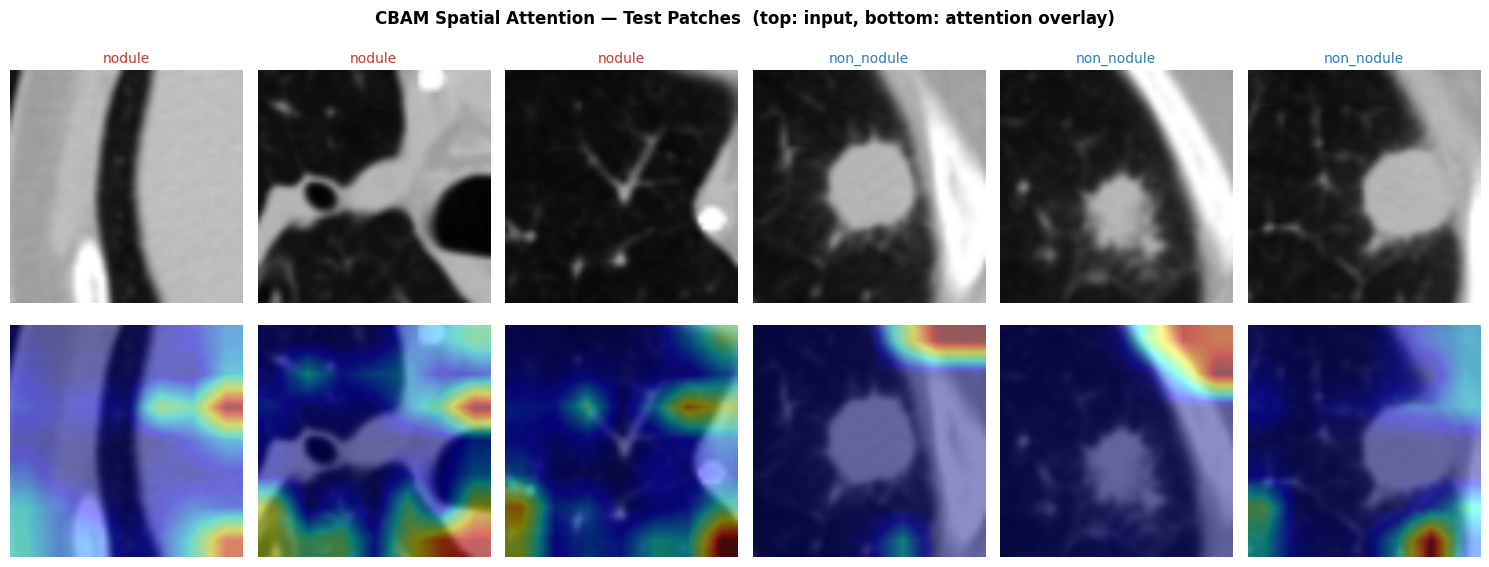

Heatmap = sigmoid output of spatial attention (red = high attention).


In [13]:
# Pull a few test patches and overlay CBAM spatial attention
fig, axes = plt.subplots(2, 6, figsize=(15, 6))
fig.suptitle("CBAM Spatial Attention — Test Patches  (top: input, bottom: attention overlay)",
             fontsize=12, fontweight="bold")

# Get a balanced sample
idx_pos = [i for i,(_,y) in enumerate(test_ds.samples) if y==1][:3]
idx_neg = [i for i,(_,y) in enumerate(test_ds.samples) if y==0][:3]
sample_idx = idx_pos + idx_neg

import torch.nn.functional as Ff
with torch.no_grad():
    for col, idx in enumerate(sample_idx):
        img, lbl = test_ds[idx]
        x = img.unsqueeze(0).to(device)
        with autocast('cuda', enabled=USE_AMP):
            _, sa_map = model.features_with_attention(x)
        sa = sa_map[0, 0].float().cpu().numpy()           # 7×7 typically
        sa = np.array(Image.fromarray(sa).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
        # Denormalize image for display
        disp = img.numpy().transpose(1,2,0) * STD + MEAN
        disp = np.clip(disp, 0, 1)
        axes[0, col].imshow(disp); axes[0, col].axis("off")
        axes[0, col].set_title(CLASS_NAMES[lbl], fontsize=10,
                                color="#c0392b" if lbl==1 else "#2980b9")
        axes[1, col].imshow(disp); axes[1, col].imshow(sa, cmap="jet", alpha=0.45)
        axes[1, col].axis("off")
plt.tight_layout(); plt.show()
print("Heatmap = sigmoid output of spatial attention (red = high attention).")


## 14 · Comparison Table — v1 (baseline) vs v2 (this notebook)

In [14]:
# Try to load v1 results
v1_path = Path("luna16_output/evaluation_report.json")
v1_path2 = Path("model_luna16/benchmark.json")

v1 = None
if v1_path.exists():
    v1 = json.loads(v1_path.read_text())
    v1_metrics = v1.get("test_threshold_0.5", {})
elif v1_path2.exists():
    v1_b = json.loads(v1_path2.read_text())
    v1_metrics = v1_b.get("test", {})
    # benchmark.json uses different key names — translate
    v1_metrics = {
        "accuracy":  v1_b['test'].get('accuracy'),
        "precision": v1_b['test'].get('precision'),
        "recall":    v1_b['test'].get('recall'),
        "f1":        v1_b['test'].get('f1'),
        "roc_auc":   v1_b['test'].get('auc'),
    }
else:
    v1_metrics = None

if v1_metrics:
    rows = ["accuracy","balanced_acc","precision","recall","specificity",
            "f1","mcc","roc_auc","pr_auc"]
    print("="*84)
    print(f"  {'Metric':<18} {'v1 baseline':>14} {'v2 single':>14} {'v2 +TTA':>14} {'Δ (v2 TTA - v1)':>17}")
    print("-"*84)
    for k in rows:
        a = v1_metrics.get(k, None)
        b = m_single.get(k)
        c = m_tta.get(k)
        if a is None:
            print(f"  {k:<18} {'(n/a)':>14} {b:>14.4f} {c:>14.4f} {'—':>17}")
        else:
            d = c - a
            sign = "+" if d>=0 else ""
            print(f"  {k:<18} {a:>14.4f} {b:>14.4f} {c:>14.4f} {sign}{d:>16.4f}")
    print("="*84)
else:
    print("v1 baseline not found at luna16_output/evaluation_report.json or model_luna16/benchmark.json")
    print("Showing v2 only:")
    for k in ["accuracy","balanced_acc","precision","recall","specificity",
              "f1","mcc","roc_auc","pr_auc"]:
        print(f"  {k:<18} single={m_single[k]:.4f}  tta={m_tta[k]:.4f}")

# Save v2 report
v2_report = {
    "dataset": "LUNA16 subsets 2+7-9 (patient-level split)",
    "split":   {"train": "subset2 + subset7", "val": "subset8", "test": "subset9"},
    "model":   {"backbone": "resnet50_cbam", "best_epoch": int(ck["epoch"])},
    "train_size": len(train_ds), "val_size": len(val_ds), "test_size": len(test_ds),
    "loss":      f"FocalLoss(alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA})",
    "augmentation": ["flip", "rotate", "color-jitter", "random-erasing", f"mixup(alpha={MIXUP_ALPHA})"],
    "test_single_pass": m_single,
    "test_tta":         m_tta,
}
(OUT_DIR/"evaluation_report.json").write_text(json.dumps(v2_report, indent=2))
print(f"\nSaved {OUT_DIR}/evaluation_report.json")


  Metric                v1 baseline      v2 single        v2 +TTA   Δ (v2 TTA - v1)
------------------------------------------------------------------------------------
  accuracy                   0.9245         0.9532         0.9653 +          0.0408
  balanced_acc               0.8961         0.9296         0.9474 +          0.0513
  precision                  0.9571         0.9692         0.9769 +          0.0198
  recall                     0.9461         0.9711         0.9788 +          0.0328
  specificity                0.8462         0.8881         0.9161 +          0.0699
  f1                         0.9516         0.9702         0.9779 +          0.0263
  mcc                        0.7806         0.8614         0.8972 +          0.1166
  roc_auc                    0.9591         0.9783         0.9852 +          0.0261
  pr_auc                     0.9837         0.9909         0.9949 +          0.0112

Saved luna16_output_v2/evaluation_report.json


## 15 · Final Summary

In [15]:
print("="*70)
print("  LUNA16 v2 — FINAL TEST RESULTS (patient-level, no leakage)")
print("="*70)
print(f"  Architecture   : ResNet-50 + CBAM (one block after layer4)")
print(f"  Loss           : Focal Loss (α={FOCAL_ALPHA}, γ={FOCAL_GAMMA})")
print(f"  Augmentation   : flip / rotate / colour-jitter / erasing + MixUp(α={MIXUP_ALPHA})")
print(f"  Inference      : 5-view TTA")
print(f"  Train data     : subset2 + subset7  ({len(train_ds)} patches)")
print(f"  Best epoch     : {ck['epoch']}")
print("-"*70)
print(f"  Test metrics @ TTA (the deployment configuration)")
print(f"    Accuracy        : {m_tta['accuracy']:.4f}")
print(f"    Balanced Acc    : {m_tta['balanced_acc']:.4f}")
print(f"    Precision       : {m_tta['precision']:.4f}")
print(f"    Recall          : {m_tta['recall']:.4f}")
print(f"    Specificity     : {m_tta['specificity']:.4f}")
print(f"    F1-Score        : {m_tta['f1']:.4f}")
print(f"    MCC             : {m_tta['mcc']:.4f}")
print(f"    ROC-AUC         : {m_tta['roc_auc']:.4f}")
print(f"    PR-AUC          : {m_tta['pr_auc']:.4f}")
print("="*70)


  LUNA16 v2 — FINAL TEST RESULTS (patient-level, no leakage)
  Architecture   : ResNet-50 + CBAM (one block after layer4)
  Loss           : Focal Loss (α=0.25, γ=2.0)
  Augmentation   : flip / rotate / colour-jitter / erasing + MixUp(α=0.4)
  Inference      : 5-view TTA
  Train data     : subset2 + subset7  (1407 patches)
  Best epoch     : 25
----------------------------------------------------------------------
  Test metrics @ TTA (the deployment configuration)
    Accuracy        : 0.9653
    Balanced Acc    : 0.9474
    Precision       : 0.9769
    Recall          : 0.9788
    Specificity     : 0.9161
    F1-Score        : 0.9779
    MCC             : 0.8972
    ROC-AUC         : 0.9852
    PR-AUC          : 0.9949
